In [2]:
import scvelo as scv
import scanpy as sc
import matplotlib.pyplot as plt
import velopotential as vp

In [3]:
adata = scv.datasets.pancreas()
scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)
scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
scv.tl.recover_dynamics(adata)
scv.tl.velocity(adata, mode='dynamical')

Filtered out 20801 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.
computing neighbors
    finished (0:00:12) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
recovering dynamics (using 1/16 cores)


  0%|          | 0/1298 [00:00<?, ?gene/s]

    finished (0:18:17) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
computing velocities
    finished (0:00:04) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


  0%|          | 0/3696 [00:00<?, ?cells/s]

computing velocity graph
finished.


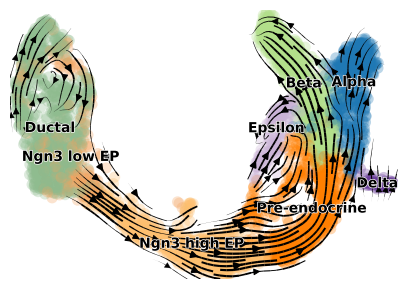

computing velocity embedding
finished.


In [4]:
vp.pl.plot_velocity_projection(adata,color="clusters",figsize=(5,3.5),xkey="Ms")

In [ ]:
vp.tl.construct_potential(adata)

epoch   1: loss=0.459280
epoch  51: loss=0.091485
epoch 101: loss=0.084943
epoch 151: loss=0.081621
epoch 201: loss=0.080599
epoch 251: loss=0.079732
epoch 301: loss=0.078333
epoch 351: loss=0.077839
Early stopping at epoch 365


  0%|          | 0/3696 [00:00<?, ?cells/s]

computing velocity graph
finished.


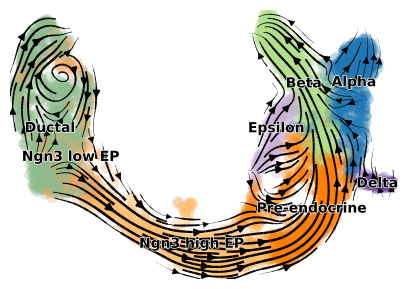

computing velocity embedding
finished.


In [6]:
vp.pl.plot_velocity_projection(adata,color="clusters",figsize=(5,3.5),vkey="velocity_pred",xkey="Ms")

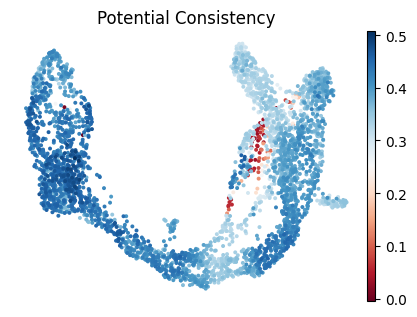

In [7]:

adata.obs['Potential Consistency'] = vp.tl.cal_cosine_similarity(adata.layers['velocity'], adata.layers['velocity_pred'])
fig, ax = plt.subplots(figsize=(5, 3.5))
sc.pl.umap(adata,color="Potential Consistency",title="Potential Consistency",frameon=False,ax=ax,cmap="RdBu")

computing terminal states
    identified 2 regions of root cells and 1 region of end points .
    finished (0:00:01) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:02) --> added 
    'latent_time', shared time (adata.obs)


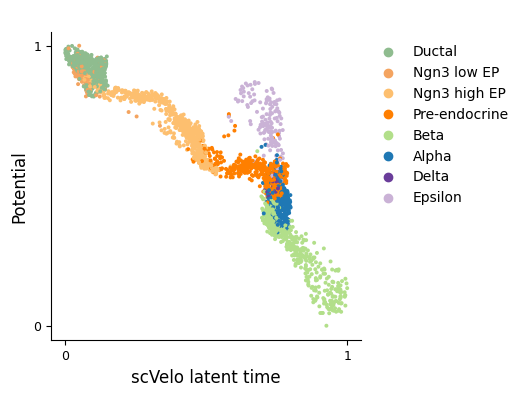

In [8]:
scv.tl.latent_time(adata)
scv.pl.scatter(adata, x='latent_time', y='potential', color='clusters',title=" ",legend_loc="upper right",fontsize=12,figsize=(4,4),xlabel="scVelo latent time",ylabel="Potential",show=False)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False) 
plt.show()

In [9]:
def potential_plot(adata):
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.interpolate import griddata
    import matplotlib.patheffects as pe
    from matplotlib.colors import LightSource

    umap1 = adata.obsm['X_umap'][:, 0]
    umap2 = adata.obsm['X_umap'][:, 1] 
    potential = adata.obs['potential'].values
    cell_types = adata.obs['clusters'].values
    unique_clusters = np.unique(cell_types)
    n_clusters = len(unique_clusters)
    auto_colors_map = {ct: adata.uns['clusters_colors'][i] for i, ct in enumerate(adata.obs['clusters'].cat.categories)}
    colors = [adata.uns['clusters_colors'][i] for i in adata.obs['clusters'].astype('category').cat.codes]
    resolution = 80
    xi = np.linspace(umap1.min() - 0.5, umap1.max() + 0.5, resolution)
    yi = np.linspace(umap2.min() - 0.5, umap2.max() + 0.5, resolution)
    Xi, Yi = np.meshgrid(xi, yi)
    Zi = griddata((umap1, umap2), potential, (Xi, Yi), method='linear')
    Zi_min = np.nanmin(potential)
    Zi = np.nan_to_num(Zi, nan=Zi_min)
    Z_range = Zi.max() - Zi.min()
    fig = plt.figure(figsize=(6,5), facecolor='white')
    ax = fig.add_subplot(111, projection='3d')
    ls = LightSource(azdeg=225, altdeg=75)
    rgb = np.ones((Zi.shape[0], Zi.shape[1], 3))
    illuminated_surface = ls.shade_rgb(rgb, Zi, vert_exag=1.2, blend_mode='overlay')
    surf = ax.plot_surface(Xi, Yi, Zi, 
                        facecolors=illuminated_surface,
                        rstride=2, cstride=2,
                        linewidth=0.15,
                        edgecolor='darkgray',
                        alpha=0.9,
                        antialiased=True,
                        shade=False)
    z_lift = Z_range * 0.04
    ax.scatter(umap1, umap2, potential + z_lift, 
               c=colors, s=5, alpha=0.85, 
               edgecolors='white', linewidth=0.1,
               depthshade=False)
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w', label=ct,
                              markerfacecolor=auto_colors_map[ct], markersize=8)
                       for ct in unique_clusters]
    ax.legend(handles=legend_elements, loc='upper left', frameon=False, fontsize=9,ncols=1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor('none')
    ax.yaxis.pane.set_edgecolor('none')
    ax.zaxis.pane.set_edgecolor('none')
    ax.xaxis.pane.set_alpha(0)
    ax.yaxis.pane.set_alpha(0)
    ax.zaxis.pane.set_alpha(0)
    ax.grid(False)
    ax.xaxis.line.set_color('none')
    ax.yaxis.line.set_color('none')
    ax.zaxis.line.set_color('none')
    ax.view_init(elev=50, azim=55)
    plt.tight_layout()
    plt.show()

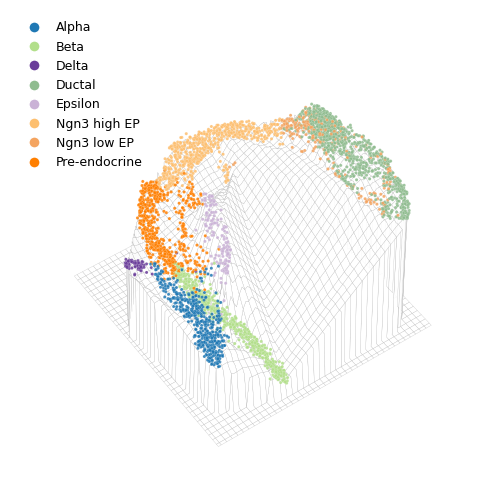

In [10]:
potential_plot(adata)